In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import json

mpl.rcParams.update({
    'axes.titlesize'   : 0,        # no title
    'axes.labelsize'   : 14,       # x and y axis labels
    'xtick.labelsize'  : 12,       # x tick labels
    'ytick.labelsize'  : 12,       # y tick labels
    'legend.fontsize'  : 12,
    'font.size'        : 12,      
})

In [2]:
df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")

/tmp/ipykernel_116929/2256054893.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")


In [3]:
import re
from tqdm.auto import tqdm

# Load lexicon
lex = pd.read_csv("vulgarity_vocabulary.csv")

terms = (
    lex["term"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
    .tolist()
)

# Separate single words vs multi-word expressions
single_words = [t for t in terms if " " not in t]
multi_words  = [t for t in terms if " " in t]

print(f"Single words: {len(single_words)} | Multi-word phrases: {len(multi_words)}")

Single words: 58 | Multi-word phrases: 3


In [4]:
# Escape regex characters
single_words_escaped = [re.escape(w) for w in single_words]
multi_words_escaped  = [re.escape(p) for p in multi_words]

# Word-boundary pattern for single words
single_word_pattern = r"\b(" + "|".join(single_words_escaped) + r")\b"

# Phrase pattern (no word boundaries inside phrases)
multi_word_pattern = r"(" + "|".join(multi_words_escaped) + r")"

# Compile regex (case-insensitive)
single_word_regex = re.compile(single_word_pattern, flags=re.IGNORECASE)
multi_word_regex  = re.compile(multi_word_pattern, flags=re.IGNORECASE)


In [5]:
def count_profanity(text):
    if not isinstance(text, str) or not text:
        return 0

    # count single words
    single_hits = single_word_regex.findall(text)

    # count multi-word phrases
    multi_hits = multi_word_regex.findall(text)

    return len(single_hits) + len(multi_hits)


def count_distinct_profanity(text):
    if not isinstance(text, str) or not text:
        return 0

    single_hits = set(m.lower() for m in single_word_regex.findall(text))
    multi_hits  = set(m.lower() for m in multi_word_regex.findall(text))

    return len(single_hits.union(multi_hits))


In [6]:
tqdm.pandas()

df["profanity_count"] = df["text"].progress_apply(count_profanity)
df["profanity_distinct"] = df["text"].progress_apply(count_distinct_profanity)

df[["text", "profanity_count", "profanity_distinct"]].head(10)


  0%|          | 0/71808 [00:00<?, ?it/s]

  0%|          | 0/71808 [00:00<?, ?it/s]

,text,profanity_count,profanity_distinct
0,"When we start talking about the economy, it's ...",0,0
1,It's no secret which groups are hit the hardes...,0,0
2,How can our elderly who have worked so hard to...,0,0
3,I believe that social security is one of this ...,0,0
4,"In contrast, I am committed to an economic pro...",0,0
5,This just doesn't make sense. Older Americans ...,0,0
6,"In fact, if you look around, you'll notice tha...",0,0
7,"More important, in today's unstable economy wi...",0,0
8,"Indeed, I believe that the earnings limitation...",0,0
9,I want to thank you for this opportunity to vi...,0,0


In [7]:
df.sort_values("profanity_count", ascending=False)[
    ["speech_par_id", "name_date", "text", "profanity_count"]
].head(20)


,speech_par_id,name_date,text,profanity_count
22574,2752_7,NaN,He called John Kennedy weak and blasted him fo...,8
67658,2020-09-03-rally-latrobe-pennsylvania_10,2020-09-03,The President. But we had record enthusiasm in...,5
67340,2020-09-21-rally-vandalia-ohio_30,2020-09-21,"But I asked him, """"""""Who's your smartest senat...",5
33484,3295_19,NaN,He said there was a politician out on the coun...,5
66812,2020-09-12-rally-minden-nevada_20,2020-09-12,The President. But now he wants to surrender o...,5
14020,3313_19,NaN,"Furthermore, as a leader of the greatest natio...",5
13430,1075_10,NaN,"Now in the end, when all of the slogans h...",5
14728,3059_9,NaN,"Anyway, Mr. Bush said Al Gore and I were crazy...",5
67205,2020-10-17-rally-janesville-wisconsin_79,2020-10-17,Joe Biden is the living embodiment of the corr...,5
12847,3058_2,NaN,"Well, there is as much difference between what...",5


In [8]:
df["profanity_count"].describe()


count    71808.000000
mean         0.040720
std          0.246437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.000000
Name: profanity_count, dtype: float64

In [9]:
df["word_count"] = df["text"].str.split().str.len()
df["profanity_per_100w"] = (
    df["profanity_count"] / df["word_count"] * 100
).fillna(0)


In [10]:
df["profanity_per_100w"].describe()

count    71808.000000
mean         0.051248
std          0.356357
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         14.285714
Name: profanity_per_100w, dtype: float64

In [11]:
df["election_year"] = df["election_date"].astype(str).str[:4].astype("Int64")



In [12]:
set(df["election_year"])

{1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016,
 2020}

In [13]:
df["person"] = (
    df["person"].astype(str)
    + "_"
    + df["election_year"].astype(str)
)


In [14]:
df_pop = df[df["Populism"] == 1]
df_non = df[df["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [15]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())


1    1861
0    1861
Name: Populism, dtype: int64


In [16]:
df_balanced[["profanity_per_100w", "Populism"]].groupby("Populism").describe()


profanity_per_100w                                                   
                      count      mean       std  min  25%  50%  75%        max
Populism                                                                      
0                    1861.0  0.059148  0.343041  0.0  0.0  0.0  0.0   5.555556
1                    1861.0  0.214119  0.702346  0.0  0.0  0.0  0.0  14.285714

In [17]:
df_balanced["has_profanity"] = (df_balanced["profanity_count"] > 0).astype(int)


In [18]:
import statsmodels.api as sm

y = df_balanced["has_profanity"]
X = sm.add_constant(df_balanced[["Populism"]])

logit = sm.Logit(y, X).fit(disp=False)
print(logit.summary())


                           Logit Regression Results                           
Dep. Variable:          has_profanity   No. Observations:                 3722
Model:                          Logit   Df Residuals:                     3720
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.05083
Time:                        10:55:25   Log-Likelihood:                -1057.8
converged:                       True   LL-Null:                       -1114.5
Covariance Type:            nonrobust   LLR p-value:                 1.855e-26
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1702      0.118    -26.896      0.000      -3.401      -2.939
Populism       1.3300      0.136      9.795      0.000       1.064       1.596


In [19]:
import statsmodels.api as sm

y = df_balanced["profanity_per_100w"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     profanity_per_100w   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     73.11
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.76e-17
Time:                        10:55:25   Log-Likelihood:                -3073.4
No. Observations:                3722   AIC:                             6151.
Df Residuals:                    3720   BIC:                             6163.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0591      0.008      7.436      0.0

In [20]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["profanity_per_100w"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)


(0.16849773495127057, 0.0074903113783972115)

In [21]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "profanity_per_100w ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())


                            OLS Regression Results                            
Dep. Variable:     profanity_per_100w   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     12.90
Date:                Mon, 04 May 2026   Prob (F-statistic):            0.00105
Time:                        10:55:26   Log-Likelihood:                -2910.7
No. Observations:                3722   AIC:                             5891.
Df Residuals:                    3687   BIC:                             6109.
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [22]:
dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_with_similarity.csv", encoding="utf-8")

/tmp/ipykernel_116929/718096552.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_with_similarity.csv", encoding="utf-8")


In [23]:
df_pop = dfllm[dfllm["Populism"] == 1]
df_non = dfllm[dfllm["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [24]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())

1    1861
0    1861
Name: Populism, dtype: int64


In [25]:
df_balanced[["agg_sim_top10", "agg_sim_max"]].describe()
df_balanced[["agg_sim_top10", "agg_sim_max"]].corr()


,agg_sim_top10,agg_sim_max
agg_sim_top10,1.000000,0.811372
agg_sim_max,0.811372,1.000000


In [26]:
for var in ["agg_sim_top10", "agg_sim_max"]:
    res = smf.ols(
        f"{var} ~ Populism + prior_president + C(person)",
        data=df_balanced
    ).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})
    print(var, res.params["Populism"], res.pvalues["Populism"])


agg_sim_top10 0.0027651535353670443 0.2867836675240676
agg_sim_max 0.014133824622439601 0.004268453851071888


In [27]:
import statsmodels.api as sm

y = df_balanced["agg_sim_top10"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          agg_sim_top10   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     48.83
Date:                Mon, 04 May 2026   Prob (F-statistic):           3.30e-12
Time:                        10:55:26   Log-Likelihood:                 6788.5
No. Observations:                3722   AIC:                        -1.357e+04
Df Residuals:                    3720   BIC:                        -1.356e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1329      0.001    149.378      0.0

In [28]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["agg_sim_top10"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(0.01001150937680675, 0.0008052811554577669)

In [29]:
import statsmodels.api as sm

y = df_balanced["agg_sim_top10"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:          agg_sim_top10   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     29.79
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.46e-13
Time:                        10:55:27   Log-Likelihood:                 6795.4
No. Observations:                3722   AIC:                        -1.358e+04
Df Residuals:                    3719   BIC:                        -1.357e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1351      0.001    1

In [30]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "agg_sim_top10 ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:          agg_sim_top10   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                 5.359e-05
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.994
Time:                        10:55:27   Log-Likelihood:                 7021.3
No. Observations:                3722   AIC:                        -1.397e+04
Df Residuals:                    3687   BIC:                        -1.375e+04
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [31]:
df.to_csv("prof_llm.csv", encoding="utf-8", index=False)

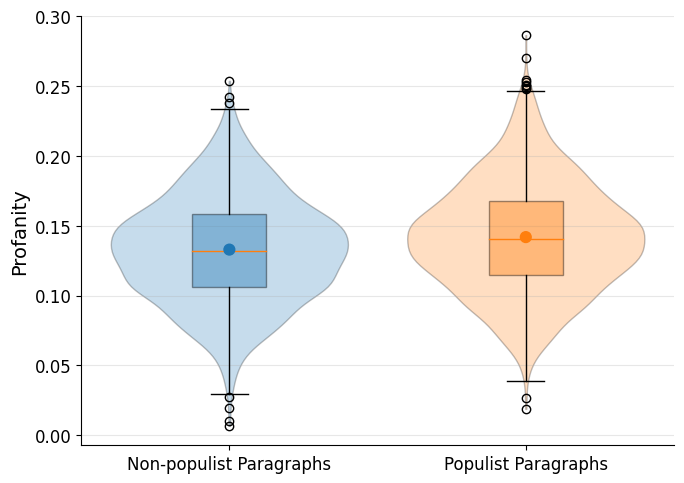

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Violin + box + mean plot (Populism on X, formality on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "agg_sim_top10"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "agg_sim_top10"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("Profanity")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("profanity_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
snippets = {
    "high_vulgarity": "Losers",
    "low_vulgarity":  "Yes. There are many initiatives that will help"
}

for label, snippet in snippets.items():
    match = df[df["text"].str.contains(snippet, regex=False, na=False)]
    print(f"\n{label}:")
    print(match[["person", "date"]].to_string())


high_vulgarity:
           person        date
67856  Biden_2020  2020-10-31
68022  Biden_2020  2020-10-29
68174  Biden_2020  2020-10-30
68225  Biden_2020  2020-11-01
68418  Biden_2020  2020-10-30
68475  Biden_2020  2020-11-02
68950  Biden_2020  2020-10-24
69008  Biden_2020  2020-09-21
69364  Biden_2020  2020-10-24
69424  Biden_2020  2020-11-02
69475  Biden_2020  2020-10-31

low_vulgarity:
          person        date
16230  Bush_1988  1988-10-05
